In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import shutil
import os

source_path = '/content/drive/MyDrive/prjct.jpg'
destination_path = '/content/prjct.jpg'
if os.path.exists(destination_path):
    shutil.rmtree(destination_path)

shutil.copytree(source_path, destination_path)

'/content/prjct.jpg'

In [ ]:
import cv2
import os

folder_path = '/content/prjct.jpg'

In [ ]:
image_files = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.png', '.jpeg'))]

loaded_images = []
for image_file in image_files:
    image_path = os.path.join(folder_path, image_file)
    img = cv2.imread(image_path)
    if img is not None:
        loaded_images.append(img)

print(f"Loaded {len(loaded_images)} images.")

Loaded 0 images.


In [ ]:
print(os.listdir(folder_path))

['best_model.keras', 'tb-hiv', 'negative']


In [ ]:
loaded_images = []
for subdir in os.listdir(folder_path):
    subdir_path = os.path.join(folder_path, subdir)
    if os.path.isdir(subdir_path):
        for image_file in os.listdir(subdir_path):
            image_path = os.path.join(subdir_path, image_file)
            if image_path.lower().endswith(('.jpg', '.png', '.jpeg')):
                img = cv2.imread(image_path)
                if img is not None:
                    loaded_images.append(img)

print(f"Loaded {len(loaded_images)} images from subdirectories.")

Loaded 280 images from subdirectories.


In [ ]:
target_size = (128, 128)
resized_images = []

for img in loaded_images:
    resized_img = cv2.resize(img, target_size)
    resized_images.append(resized_img)

print(f"Resized {len(resized_images)} images to {target_size}.")

Resized 280 images to (128, 128).


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
resized_images_array = np.array(resized_images)

if resized_images_array.ndim == 3:
    resized_images_array = np.expand_dims(resized_images_array, axis=-1)

resized_images_array = resized_images_array.astype('float32') / 255.0

datagen = ImageDataGenerator(
    rotation_range=45,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip= True,
    fill_mode='nearest'
)

num_augmented_images_to_generate = len(resized_images) * 2
augmented_images = []
i = 0
for batch in datagen.flow(resized_images_array, batch_size=32):
    for augmented_img in batch:
        augmented_images.append((augmented_img * 255).astype(np.uint8))
        i += 1
        if i >= num_augmented_images_to_generate:
            break
    if i >= num_augmented_images_to_generate:
        break

print(f"Generated {len(augmented_images)} augmented images.")

Generated 560 augmented images.


In [ ]:
import random

random.shuffle(augmented_images)

print(f"Shuffled {len(augmented_images)} augmented images.")

Shuffled 560 augmented images.


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import os
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

image_paths_with_labels = []
folder_path = '/content/prjct.jpg'

for subdir in os.listdir(folder_path):
    subdir_path = os.path.join(folder_path, subdir)
    if os.path.isdir(subdir_path) and subdir in ['tb-hiv', 'negative']:
        label = subdir
        for image_file in os.listdir(subdir_path):
            image_path = os.path.join(subdir_path, image_file)
            if image_path.lower().endswith(('.jpg', '.png', '.jpeg')):
                image_paths_with_labels.append((image_path, label))

original_images_resized = []
original_labels = []
target_size = (128, 128)

for subdir in os.listdir(folder_path):
    subdir_path = os.path.join(folder_path, subdir)
    if os.path.isdir(subdir_path) and subdir in ['tb-hiv', 'negative']:
        label = subdir
        for image_file in os.listdir(subdir_path):
            image_path = os.path.join(subdir_path, image_file)
            if image_path.lower().endswith(('.jpg', '.png', '.jpeg')):
                img = cv2.imread(image_path)
                if img is not None:

                    resized_img = cv2.resize(img, target_size)
                    original_images_resized.append(resized_img)
                    original_labels.append(label)

label_map = {'negative': 0, 'tb-hiv': 1}
numerical_labels = np.array([label_map[label] for label in original_labels])

original_images_array = np.array(original_images_resized)


X_train_orig, X_temp, y_train_orig, y_temp = train_test_split(
    original_images_array, numerical_labels, test_size=0.3, random_state=42, stratify=numerical_labels
)
X_val_orig, X_test_orig, y_val_orig, y_temp = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Original training set size: {len(X_train_orig)}")
print(f"Original validation set size: {len(X_val_orig)}")
print(f"Original test set size: {len(X_test_orig)}")
print(f"Original training labels size: {len(y_train_orig)}")

datagen = ImageDataGenerator(
    rotation_range=40,       # Increased from 20
    width_shift_range=0.3,  # Increased from 0.2
    height_shift_range=0.3, # Increased from 0.2
    shear_range=0.3,        # Increased from 0.2
    zoom_range=0.3,        # Increased from 0.2
    horizontal_flip=True,
    vertical_flip=True,
        # Added vertical flip
    fill_mode='nearest'
)

augmented_train_images = []
augmented_train_labels = []

X_train_augmented_input = X_train_orig.astype('float32') / 255.0

images_per_original_train_image = 3

i = 0

for x_batch, y_batch in datagen.flow(X_train_augmented_input, y_train_orig, batch_size=1):
    for augmented_img, augmented_label in zip(x_batch, y_batch):

        augmented_train_images.append((augmented_img * 255).astype(np.uint8))
        augmented_train_labels.append(augmented_label)
        i += 1

        if i >= len(X_train_orig) * images_per_original_train_image:
            break
    if i >= len(X_train_orig) * images_per_original_train_image:
        break

X_train_final = np.array(augmented_train_images)
y_train_final = np.array(augmented_train_labels)

X_val_final = X_val_orig
y_val_final = y_val_orig
X_test_final = X_test_orig
y_test_final = y_temp

X_train_final = X_train_final.astype('float32') / 255.0
X_val_final = X_val_final.astype('float32') / 255.0
X_test_final = X_test_final.astype('float32') / 255.0


print(f"Final training set size: {len(X_train_final)}")
print(f"Final validation set size: {len(X_val_final)}")
print(f"Final test set size: {len(X_test_final)}")

Original training set size: 196
Original validation set size: 42
Original test set size: 42
Original training labels size: 196
Final training set size: 588
Final validation set size: 42
Final test set size: 42


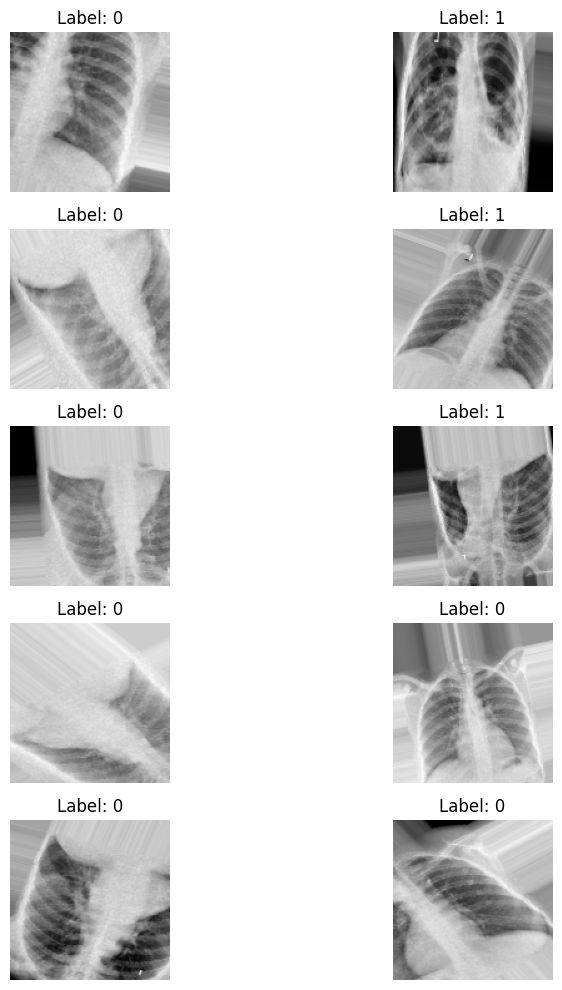

In [ ]:
import matplotlib.pyplot as plt
num_samples_to_show = 10

plt.figure(figsize=(10, 10))
for i in range(num_samples_to_show):
    plt.subplot(5, 2, i + 1)
    plt.imshow(X_train_final[i])
    plt.title(f"Label: {y_train_final[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

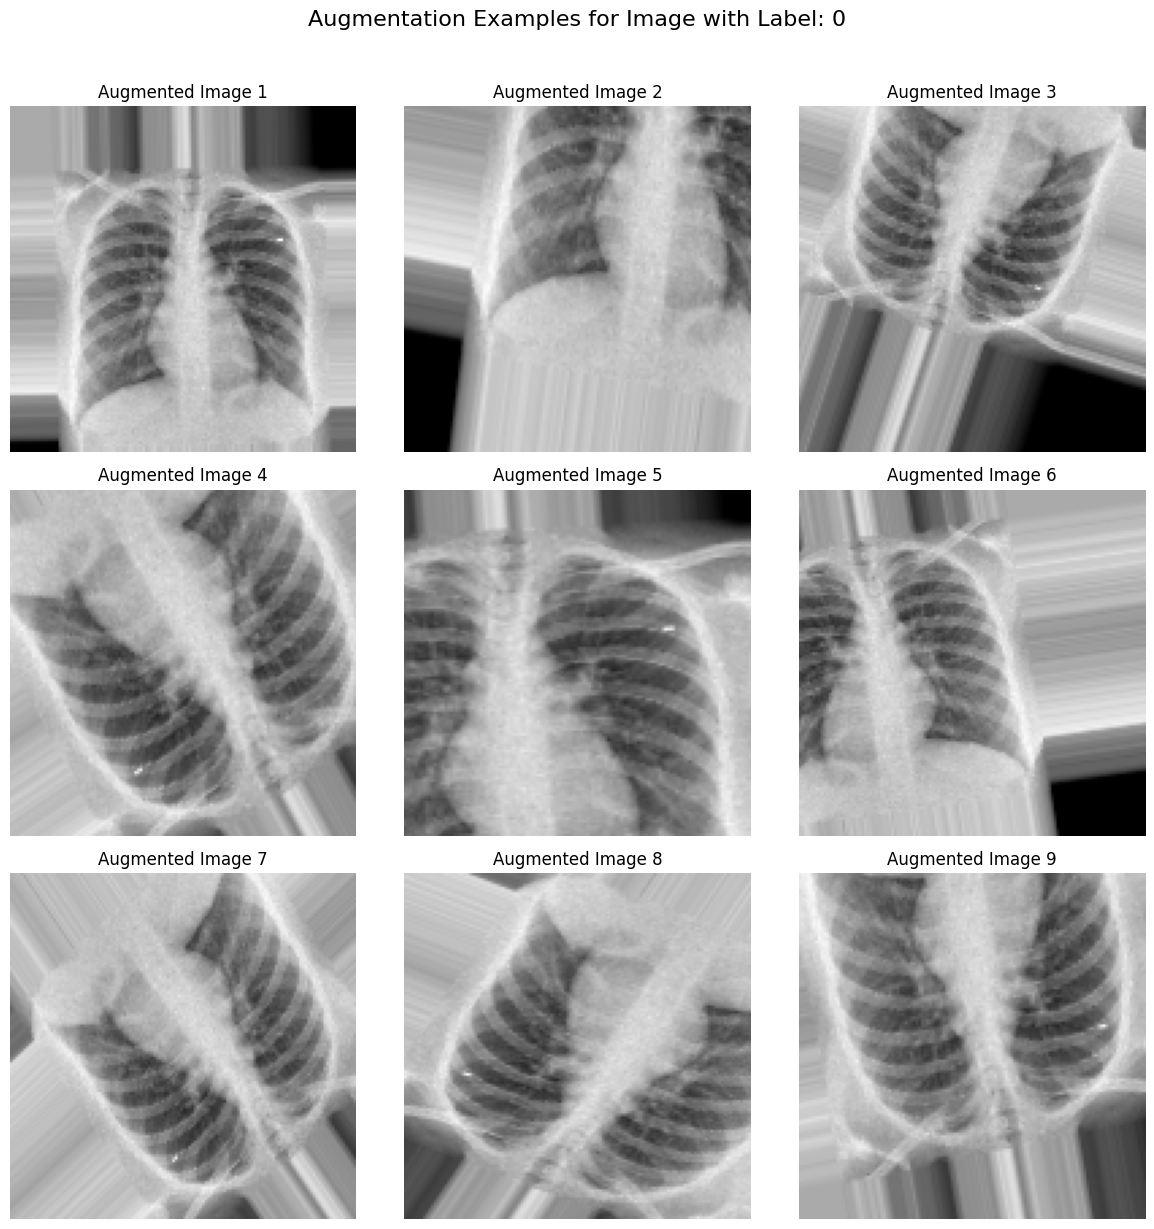

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

sample_image = X_train_orig[0]
sample_label = y_train_orig[0]

sample_image = np.expand_dims(sample_image, axis=0)

sample_image = sample_image.astype('float32') / 255.0

plt.figure(figsize=(12, 12))
plt.suptitle(f"Augmentation Examples for Image with Label: {sample_label}", y=1.02, fontsize=16)

i = 0
for batch in datagen.flow(sample_image, batch_size=1):
    augmented_img = batch[0]
    plt.subplot(3, 3, i + 1)
    plt.imshow((augmented_img * 255).astype(np.uint8))
    plt.title(f"Augmented Image {i + 1}")
    plt.axis('off')
    i += 1
    if i % 9 == 0:
        break

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(target_size[0], target_size[1], 3))

train_features = base_model.predict(X_train_final)
val_features = base_model.predict(X_val_final)
test_features = base_model.predict(X_test_final)

train_features_flat = train_features.reshape(train_features.shape[0], -1)
val_features_flat = val_features.reshape(val_features.shape[0], -1)
test_features_flat = test_features.reshape(test_features.shape[0], -1)

print(f"Shape of flattened training features: {train_features_flat.shape}")
print(f"Shape of flattened validation features: {val_features_flat.shape}")
print(f"Shape of flattened test features: {test_features_flat.shape}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 129s 7s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step
Shape of flattened training features: (588, 8192)
Shape of flattened validation features: (42, 8192)
Shape of flattened test features: (42, 8192)


In [ ]:

for layer in base_model.layers:
    layer.trainable = False

print("Convolutional base of the VGG16 model has been frozen.")

Convolutional base of the VGG16 model has been frozen.


In [ ]:
unfreeze_from_layer = None
# Try unfreezing from an earlier layer, for example, 'block2_conv1'
for i, layer in enumerate(base_model.layers):
    if layer.name == 'block3_conv1':
        unfreeze_from_layer = i
        break

if unfreeze_from_layer is not None:
    for layer in base_model.layers[unfreeze_from_layer:]:
        layer.trainable = True
    print(f"Unfrozen layers starting from '{base_model.layers[unfreeze_from_layer].name}'.")
else:
    print("Could not find the specified layer to start unfreezing.")
for layer in base_model.layers:
    print(f"Layer: {layer.name}, Trainable: {layer.trainable}")

Unfrozen layers starting from 'block3_conv1'.
Layer: input_layer, Trainable: False
Layer: block1_conv1, Trainable: False
Layer: block1_conv2, Trainable: False
Layer: block1_pool, Trainable: False
Layer: block2_conv1, Trainable: False
Layer: block2_conv2, Trainable: False
Layer: block2_pool, Trainable: False
Layer: block3_conv1, Trainable: True
Layer: block3_conv2, Trainable: True
Layer: block3_conv3, Trainable: True
Layer: block3_pool, Trainable: True
Layer: block4_conv1, Trainable: True
Layer: block4_conv2, Trainable: True
Layer: block4_conv3, Trainable: True
Layer: block4_pool, Trainable: True
Layer: block5_conv1, Trainable: True
Layer: block5_conv2, Trainable: True
Layer: block5_conv3, Trainable: True
Layer: block5_pool, Trainable: True


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import Flatten, Dense, BatchNormalization, Dropout, Input
from tensorflow.keras.regularizers import l2 # Import l2
input_tensor = Input(shape=(target_size[0], target_size[1], 3))
x = base_model(input_tensor)
x = Flatten()(x)

x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
output_tensor = Dense(1, activation='sigmoid')(x)

fine_tune_model = Model(inputs=input_tensor, outputs=output_tensor)
fine_tune_model.compile(optimizer=SGD(learning_rate=0.001),
                        loss='binary_crossentropy',
                        metrics=['accuracy'])

fine_tune_model.summary()
print("Model compiled for fine-tuning with more regularization.")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,772,481 (60.17 MB)

 Trainable params: 15,511,937 (59.17 MB)

 Non-trainable params: 260,544 (1017.75 KB)

Model compiled for fine-tuning with more regularization.


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import os
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# ... (rest of your data loading and preprocessing code)

fine_tune_epochs = 40
history_fine_tune = fine_tune_model.fit(X_train_final, y_train_final,
                                        epochs=fine_tune_epochs,
                                        batch_size=32,
                                        validation_data=(X_val_final, y_val_final))




print("Model fine-tuning complete.")

Epoch 1/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 339s 18s/step - accuracy: 0.5229 - loss: 4.3936 - val_accuracy: 0.5952 - val_loss: 4.0402
Epoch 2/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 386s 18s/step - accuracy: 0.6208 - loss: 4.2183 - val_accuracy: 0.5000 - val_loss: 4.1788
Epoch 3/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 375s 18s/step - accuracy: 0.5209 - loss: 4.2946 - val_accuracy: 0.5000 - val_loss: 4.3572
Epoch 4/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 395s 18s/step - accuracy: 0.5701 - loss: 4.2550 - val_accuracy: 0.5000 - val_loss: 4.2868
Epoch 5/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 373s 18s/step - accuracy: 0.6751 - loss: 4.0393 - val_accuracy: 0.5000 - val_loss: 4.0272
Epoch 6/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 386s 18s/step - accuracy: 0.6810 - loss: 4.0179 - val_accuracy: 0.4762 - val_loss: 4.0425
Epoch 7/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 387s 18s/step - accuracy: 0.6679 - loss: 4.0531 - val_accuracy: 0.5000 - val_loss: 4.8409
Epoch 8/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 337s 18s/step - accuracy: 0.6649 - loss: 4.0379 - val_accuracy: 0.

In [ ]:

loss, accuracy = fine_tune_model.evaluate(X_test_final,y_test_final , verbose=0)

print(f"Test Loss after fine-tuning: {loss:.4f}")
print(f"Test Accuracy after fine-tuning: {accuracy:.4f}")

In [ ]:
from sklearn.metrics import f1_score
import numpy as np
y_pred_prob_test = fine_tune_model.predict(X_test_final,)
y_pred_test = (y_pred_prob_test > 0.3).astype(int)
f1_test = f1_score(y_test_final, y_pred_test)

print(f"F1 Score on the test set: {f1_test:.4f}")

y_pred_prob_train = fine_tune_model.predict(X_train_final)

y_pred_train = (y_pred_prob_train > 0.3).astype(int)

f1_train = f1_score(y_train_final, y_pred_train)

print(f"F1 Score on the training set: {f1_train:.4f}")

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_final, y_pred_test)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'TB-HIV'], yticklabels=['Negative', 'TB-HIV'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_fine_tune.history['accuracy'])
plt.plot(history_fine_tune.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history_fine_tune.history['loss'])
plt.plot(history_fine_tune.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
import shutil
import os

source_path = '/content/drive/MyDrive/test_renamed'
destination_path = '/content/test_renamed'

if os.path.exists(destination_path):
    if os.path.isdir(destination_path):
        shutil.rmtree(destination_path)
    else:
        os.remove(destination_path)
shutil.copytree(source_path, destination_path)
print(f"Copied '{source_path}' to '{destination_path}'")

In [ ]:
import cv2
import os
import numpy as np

test_folder_path = '/content/test_renamed'
target_size = (128, 128)

test_images_resized = []
test_labels = []
label_map = {'negative': 0, 'tb-hiv': 1}

for subdir in os.listdir(test_folder_path):
    subdir_path = os.path.join(test_folder_path, subdir)
    if os.path.isdir(subdir_path) and subdir in ['tb-hiv', 'negative']:
        label = subdir
        for image_file in os.listdir(subdir_path):
            image_path = os.path.join(subdir_path, image_file)
            if image_path.lower().endswith(('.jpg', '.png', '.jpeg')):
                img = cv2.imread(image_path)
                if img is not None:
                    resized_img = cv2.resize(img, target_size)
                    test_images_resized.append(resized_img)
                    test_labels.append(label)

X_external_test = np.array(test_images_resized)
y_external_test = np.array([label_map[label] for label in test_labels])


X_external_test = X_external_test.astype('float32') / 255.0

print(f"Loaded and preprocessed {len(X_external_test)} images from the external test folder.")

In [ ]:

loss_external, accuracy_external = fine_tune_model.evaluate(X_external_test, y_external_test, verbose=0)

print(f"External Test Loss: {loss_external:.4f}")
print(f"External Test Accuracy: {accuracy_external:.4f}")

In [ ]:
from sklearn.metrics import f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred_prob_external = fine_tune_model.predict(X_external_test)

y_pred_external = (y_pred_prob_external > 0.3).astype(int)

# Calculate F1 score
f1_external = f1_score(y_external_test, y_pred_external)
print(f"F1 Score on the external test set: {f1_external:.4f}")

cm_external = confusion_matrix(y_external_test, y_pred_external)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_external, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'TB-HIV'], yticklabels=['Negative', 'TB-HIV'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on External Test Set')
plt.show()